In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import csv
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [21]:
dataset = '../model/keypoint_classifier/keypoint.csv'
model_save_path = '../model/keypoint_classifier/keypoint_classifier.keras'

In [22]:
NUM_CLASSES = 34

In [23]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [24]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=42)

In [26]:
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(21 * 2,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

C:\Users\Prajwal H\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [27]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
1/6 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.0234 - loss: 3.5766
Epoch 1: saving model to ../model/keypoint_classifier/keypoint_classifier.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.0349 - loss: 3.4927 - val_accuracy: 0.0000e+00 - val_loss: 3.3397
Epoch 2/1000
1/6 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - accuracy: 0.1406 - loss: 3.2855
Epoch 2: saving model to ../model/keypoint_classifier/keypoint_classifier.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1130 - loss: 3.2056 - val_accuracy: 0.1125 - val_loss: 3.0126
Epoch 3/1000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.1172 - loss: 3.1031
Epoch 3: saving model to ../model/keypoint_classifier/keypoint_classifier.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1506 - loss: 2.9358 - val_accuracy: 0.2083 - val_loss: 2.6761
Epoch 4/1000
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1016 - loss: 2.7506
Epoch 4: saving model to ../model/keypoint_classifier/keypoint_classifier.

In [30]:
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 4.6604e-04


In [31]:
model = tf.keras.models.load_model(model_save_path)

In [32]:
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
[9.9153856e-13 1.4401182e-06 3.2483316e-10 3.3865701e-03 1.3744786e-13
 8.2330809e-11 1.2825815e-06 2.2714747e-11 9.9660707e-01 3.6037634e-06
 7.2525153e-11 5.7619274e-12 5.4792056e-12 7.1722607e-11 9.2106956e-12
 3.4311689e-11 9.7648001e-11 5.6429427e-12 8.1198763e-11 2.7952994e-11
 9.4057206e-11 3.4583964e-11 1.9155410e-11 9.3364774e-11 3.4075336e-11
 3.4267721e-12 4.2206436e-11 8.2345537e-12 9.3556045e-11 1.8269652e-10
 7.6215588e-12 2.2248749e-10 2.4054383e-10 5.2023337e-11]
8


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


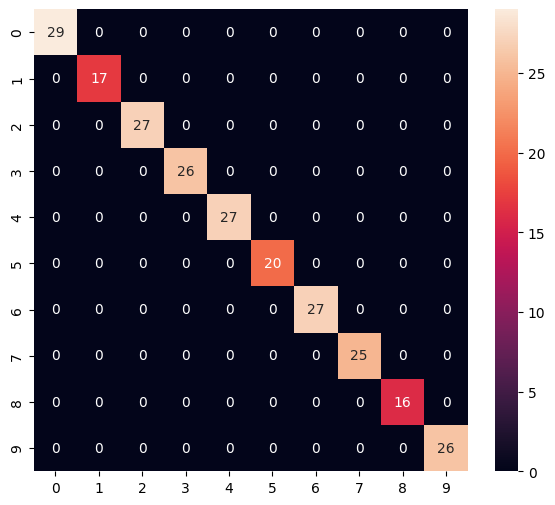

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        27
           7       1.00      1.00      1.00        25
           8       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        26

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

In [34]:
model.save(model_save_path, include_optimizer=False)

In [35]:
tflite_save_path = '../model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\PRAJWA~1\AppData\Local\Temp\tmpwo7sk1c6\assets


INFO:tensorflow:Assets written to: C:\Users\PRAJWA~1\AppData\Local\Temp\tmpwo7sk1c6\assets


Saved artifact at 'C:\Users\PRAJWA~1\AppData\Local\Temp\tmpwo7sk1c6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 34), dtype=tf.float32, name=None)
Captures:
  1826314171024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826314174288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826314173712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826314171600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826314172944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826314169488: TensorSpec(shape=(), dtype=tf.resource, name=None)


21568

In [36]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

C:\Users\Prajwal H\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [37]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [38]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [39]:
%%time
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [40]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[9.9965056e-13 1.4730804e-06 2.8346606e-10 3.0063754e-03 1.4037948e-13
 7.9686417e-11 1.2807466e-06 2.0612382e-11 9.9698716e-01 3.6634715e-06
 7.0404065e-11 5.6816483e-12 5.3845743e-12 6.9606668e-11 9.1394860e-12
 3.3528742e-11 9.7345604e-11 5.4938970e-12 7.7807684e-11 2.7013140e-11
 9.2311707e-11 3.2986835e-11 1.7882473e-11 9.1773797e-11 3.3577061e-11
 3.3672347e-12 4.0781274e-11 8.1438953e-12 8.9220048e-11 1.7349298e-10
 7.4704938e-12 2.1617511e-10 2.3293811e-10 5.0470749e-11]
8
